<h1>ENRIQUEZ ACTIVITY 6</h1>

In [1]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.stats import f_oneway
import calendar

In [3]:
Global = pd.read_csv('datasets//Global_terrorist.csv', encoding='latin1')

C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_21296\159967897.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  Global = pd.read_csv('datasets//Global_terrorist.csv', encoding='latin1')


In [4]:
Global

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181686,201712310022,2017,12,31,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Attack Army Che...","""Highlights: Somalia Daily Media Highlights 2 ...","""Highlights: Somalia Daily Media Highlights 1 ...",START Primary Collection,0,0,0,0,NaN
181687,201712310029,2017,12,31,NaN,0,NaN,200,Syria,10,...,NaN,"""Putin's 'victory' in Syria has turned into a ...","""Two Russian soldiers killed at Hmeymim base i...","""Two Russian servicemen killed in Syria mortar...",START Primary Collection,-9,-9,1,1,NaN
181688,201712310030,2017,12,31,NaN,0,NaN,160,Philippines,5,...,NaN,"""Maguindanao clashes trap tribe members,"" Phil...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
181689,201712310031,2017,12,31,NaN,0,NaN,92,India,6,...,NaN,"""Trader escapes grenade attack in Imphal,"" Bus...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN


<h1>insights 1 : Top 10 Countries by Number of Attacks</h1>

C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_21296\755868018.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set2')


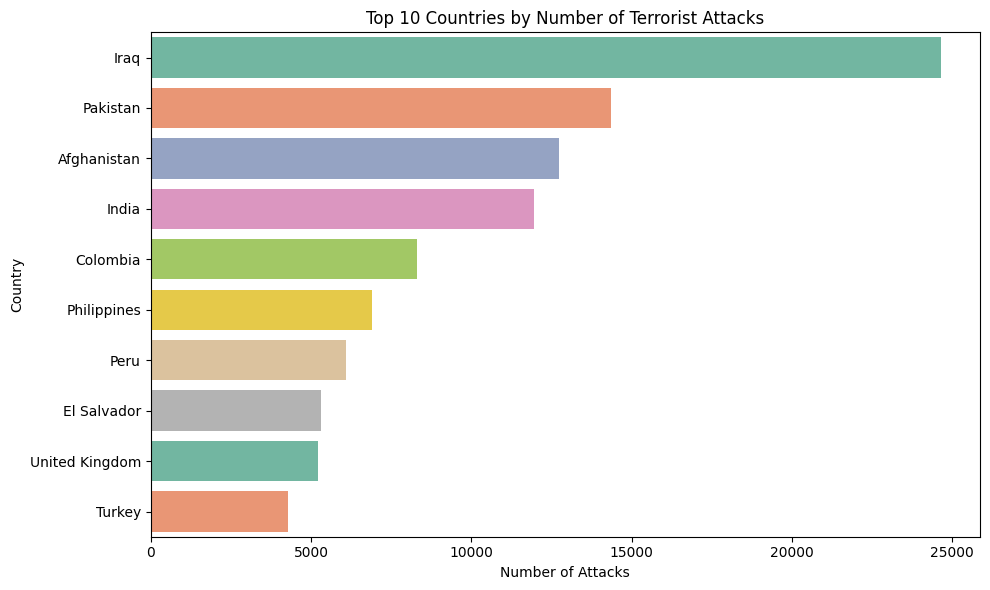

country_txt
Iraq              24636
Pakistan          14368
Afghanistan       12731
India             11960
Colombia           8306
Philippines        6908
Peru               6096
El Salvador        5320
United Kingdom     5235
Turkey             4292
Name: count, dtype: int64

In [12]:
top_countries = Global['country_txt'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set2')
plt.title('Top 10 Countries by Number of Terrorist Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

top_countries

<h1>Insights 2 :Top 10 Terrorist Groups (Excluding "Unknown")</h1>

C:\Users\JUSTINEENRIQUEZ\AppData\Local\Temp\ipykernel_21296\2205007035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_groups.values, y=top_groups.index, palette='rocket')


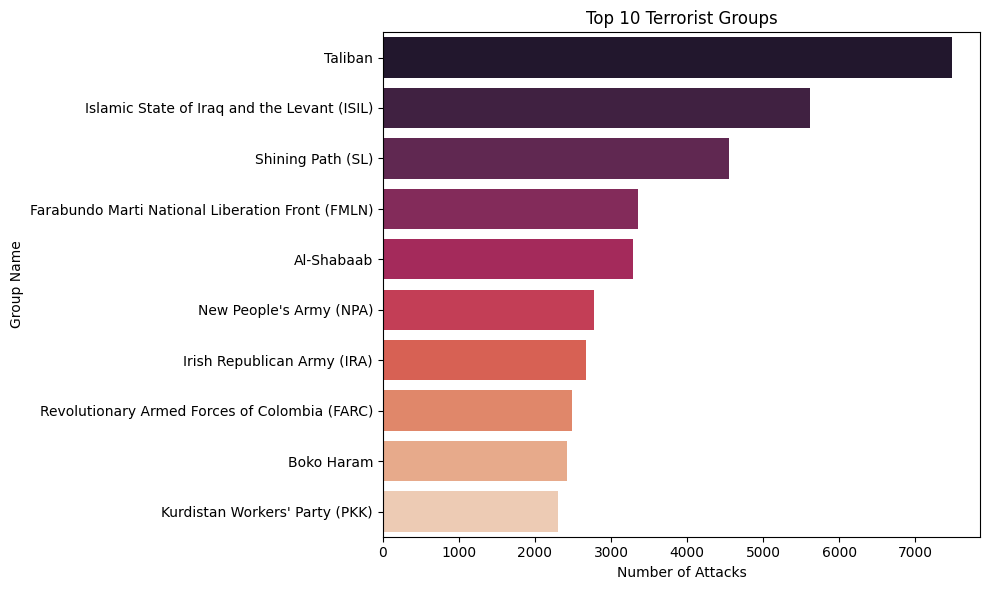

gname
Taliban                                             7478
Islamic State of Iraq and the Levant (ISIL)         5613
Shining Path (SL)                                   4555
Farabundo Marti National Liberation Front (FMLN)    3351
Al-Shabaab                                          3288
New People's Army (NPA)                             2772
Irish Republican Army (IRA)                         2671
Revolutionary Armed Forces of Colombia (FARC)       2487
Boko Haram                                          2418
Kurdistan Workers' Party (PKK)                      2310
Name: count, dtype: int64

In [11]:
top_groups = Global[Global['gname'] != 'Unknown']['gname'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_groups.values, y=top_groups.index, palette='rocket')
plt.title('Top 10 Terrorist Groups')
plt.xlabel('Number of Attacks')
plt.ylabel('Group Name')
plt.tight_layout()
plt.show()

top_groups

<h1>insights 3: Number of Attacks per Year</h1>

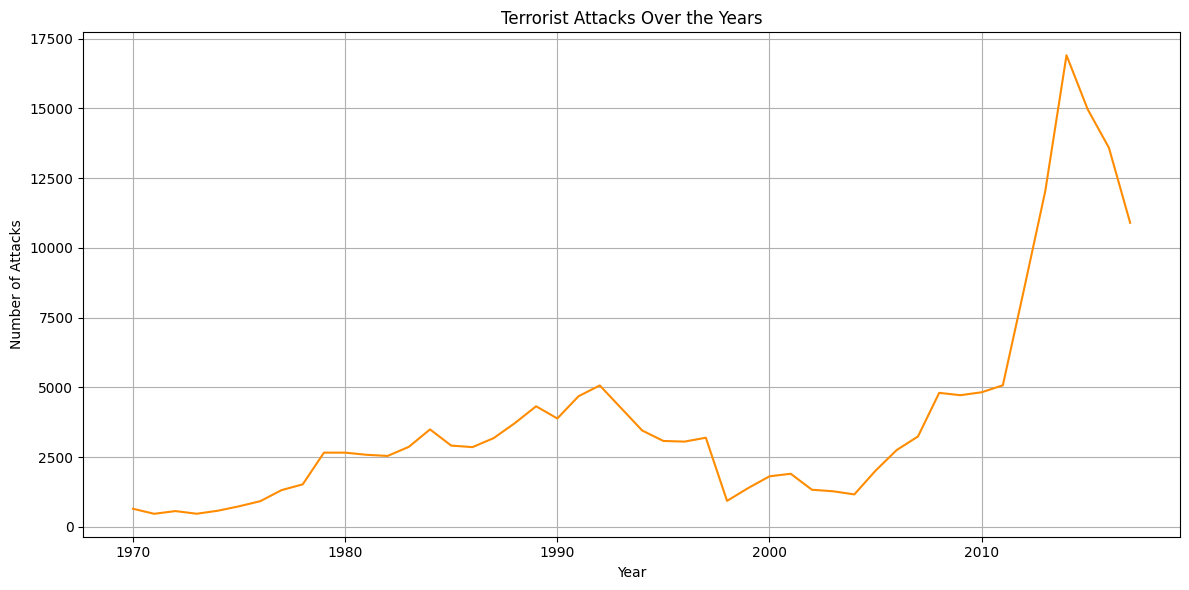

iyear
1970      651
1971      471
1972      568
1973      473
1974      581
1975      740
1976      923
1977     1319
1978     1526
1979     2662
1980     2662
1981     2586
1982     2544
1983     2870
1984     3495
1985     2915
1986     2860
1987     3183
1988     3721
1989     4324
1990     3887
1991     4683
1992     5071
1994     3456
1995     3081
1996     3058
1997     3197
1998      934
1999     1395
2000     1814
2001     1906
2002     1333
2003     1278
2004     1166
2005     2017
2006     2758
2007     3242
2008     4805
2009     4721
2010     4826
2011     5076
2012     8522
2013    12036
2014    16903
2015    14965
2016    13587
2017    10900
Name: count, dtype: int64

In [10]:
attacks_per_year = Global['iyear'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=attacks_per_year.index, y=attacks_per_year.values, color='darkorange')
plt.title('Terrorist Attacks Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.tight_layout()
plt.show()
attacks_per_year

<h1>insights 4: Casualties Over the Years (Killed + Wounded)</h1>

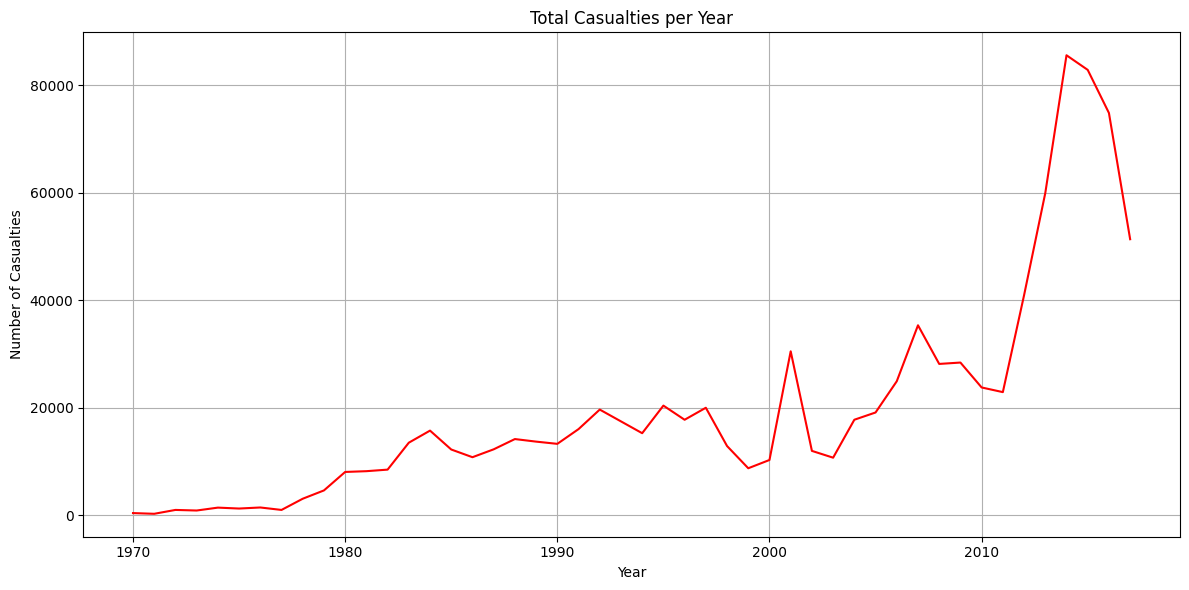

iyear
1970      386.0
1971      255.0
1972      975.0
1973      865.0
1974     1404.0
1975     1234.0
1976     1430.0
1977      974.0
1978     3059.0
1979     4606.0
1980     8045.0
1981     8188.0
1982     8478.0
1983    13491.0
1984    15741.0
1985    12224.0
1986    10790.0
1987    12257.0
1988    14168.0
1989    13691.0
1990    13276.0
1991    16020.0
1992    19657.0
1994    15259.0
1995    20395.0
1996    17761.0
1997    19996.0
1998    12871.0
1999     8734.0
2000    10272.0
2001    30503.0
2002    11967.0
2003    10701.0
2004    17765.0
2005    19115.0
2006    24930.0
2007    35348.0
2008    28155.0
2009    28411.0
2010    23774.0
2011    22905.0
2012    40942.0
2013    59961.0
2014    85618.0
2015    82896.0
2016    74872.0
2017    51372.0
Name: casualties, dtype: float64

In [13]:
Global['casualties'] = Global['nkill'].fillna(0) + Global['nwound'].fillna(0)
casualties_per_year = Global.groupby('iyear')['casualties'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=casualties_per_year.index, y=casualties_per_year.values, color='red')
plt.title('Total Casualties per Year')
plt.xlabel('Year')
plt.ylabel('Number of Casualties')
plt.grid(True)
plt.tight_layout()
plt.show()

casualties_per_year

<h1>insights 5: Distribution of Attack Types</h1>

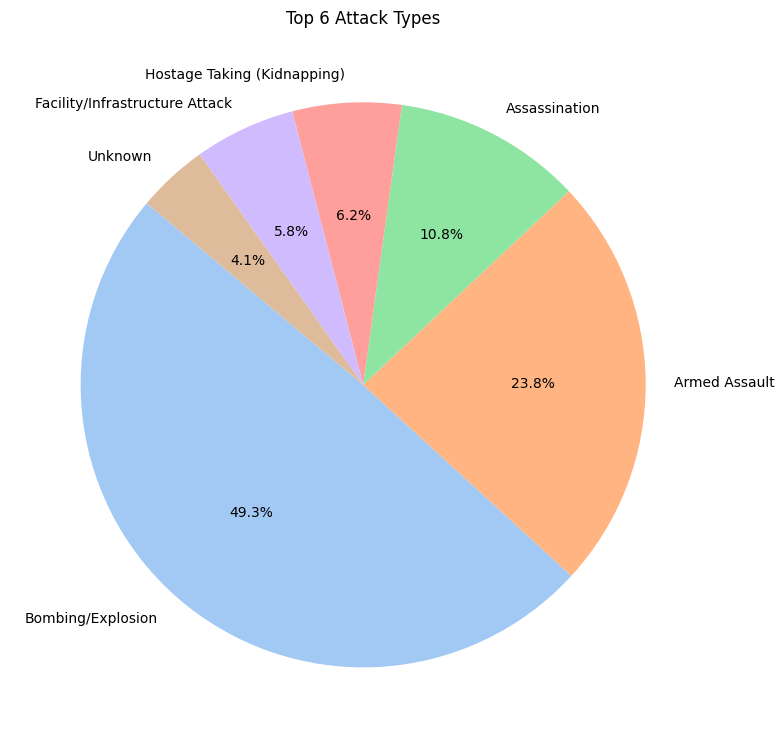

attacktype1_txt
Bombing/Explosion                 88255
Armed Assault                     42669
Assassination                     19312
Hostage Taking (Kidnapping)       11158
Facility/Infrastructure Attack    10356
Unknown                            7276
Name: count, dtype: int64

In [15]:
attack_distribution = Global['attacktype1_txt'].value_counts().nlargest(6)
colors = sns.color_palette('pastel')[0:6]

plt.figure(figsize=(8, 8))
plt.pie(attack_distribution, labels=attack_distribution.index, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Top 6 Attack Types')
plt.tight_layout()
plt.show()

attack_distribution

<h1>insights 6: Correlation Between Casualty-related Fields</h1>

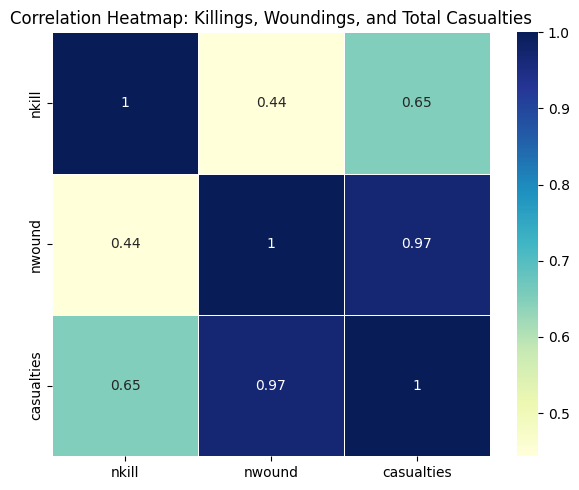

,nkill,nwound,casualties
nkill,1.000000,0.443326,0.651885
nwound,0.443326,1.000000,0.968724
casualties,0.651885,0.968724,1.000000


In [17]:
heatmap_data = Global[['nkill', 'nwound', 'casualties']].fillna(0).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Correlation Heatmap: Killings, Woundings, and Total Casualties')
plt.tight_layout()
plt.show()

heatmap_data